## 0 — Imports & Setup

In [1]:
import os, sys

ROOT= os.path.expanduser('~/QIAO0042/models/ineedfood/')
os.chdir(ROOT)

print('Working dir:', os.getcwd())

Working dir: /scratch-share/QIAO0042/models/ineedfood


In [2]:
import os, zipfile, random, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder

from PIL import Image
import wandb

print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# # Reproducibility
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

PyTorch 2.10.0+cu128  |  CUDA available: True
Using device: cuda


## 2 — Data Preprocessing

In [3]:
# ── Copy pre-resized images from NFS → local /tmp (fast SSD) ─────────────────
# Images are already 100×100 in NFS_CACHE (written by preprocess.ipynb).
# This cell copies them to /tmp so dataloaders read from local disk each session.
import shutil
from pathlib import Path

NFS_CACHE   = 'dataset/food11_100x100'
LOCAL_CACHE = '/tmp/ineedfood_100x100'

def _sync_to_tmp(src_root, dst_root):
    src_root, dst_root = Path(src_root), Path(dst_root)
    for split in ('training', 'validation', 'evaluation'):
        src = src_root / split
        dst = dst_root / split
        n_src = len(list(src.rglob('*.jpg')))
        n_dst = len(list(dst.rglob('*.jpg'))) if dst.exists() else 0
        if n_dst == n_src:
            print(f'  {split:12s} — already in /tmp ({n_dst} files), skipping')
        else:
            print(f'  {split:12s} — copying {n_src} files ...')
            if dst.exists():
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f'  {split:12s} — done')

print(f'Syncing {NFS_CACHE} → {LOCAL_CACHE} ...')
if not Path(LOCAL_CACHE).exists():
    _sync_to_tmp(NFS_CACHE, LOCAL_CACHE)
else:
    print(f'  Cache already exists at {LOCAL_CACHE}, skipping sync')

TRAIN_DIR = str(Path(LOCAL_CACHE) / 'training')
VAL_DIR   = str(Path(LOCAL_CACHE) / 'validation')
TEST_DIR  = str(Path(LOCAL_CACHE) / 'evaluation')
print(f'\nTRAIN_DIR → {TRAIN_DIR}')
print(f'VAL_DIR   → {VAL_DIR}')
print(f'TEST_DIR  → {TEST_DIR}')

Syncing dataset/food11_100x100 → /tmp/ineedfood_100x100 ...
  Cache already exists at /tmp/ineedfood_100x100, skipping sync

TRAIN_DIR → /tmp/ineedfood_100x100/training
VAL_DIR   → /tmp/ineedfood_100x100/validation
TEST_DIR  → /tmp/ineedfood_100x100/evaluation


In [4]:
from pathlib import Path

class Food11Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

        for p in self.root.iterdir():
            if p.is_file() and p.suffix.lower() in exts:
                stem = p.stem
                if "_" not in stem:
                    continue
                cls = int(stem.split("_")[0])   # e.g., 10_200.jpg -> 10
                self.samples.append((p, cls))

        if not self.samples:
            raise RuntimeError(f"No valid images found in {root_dir}")

        self.classes = [str(i) for i in range(11)]
        self.class_to_idx = {c: int(c) for c in self.classes}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [5]:
import json

STATS_FILE = 'dataset/stats.json'
assert os.path.exists(STATS_FILE), \
    f'{STATS_FILE} not found — run preprocess.ipynb first'

with open(STATS_FILE) as f:
    _stats = json.load(f)

MEAN        = _stats['mean']
STD         = _stats['std']
NUM_CLASSES = _stats['num_classes']
NFS_CACHE   = _stats['nfs_cache']

print(f'Loaded stats from {STATS_FILE}')
print(f'  mean        : {[f"{v:.4f}" for v in MEAN]}')
print(f'  std         : {[f"{v:.4f}" for v in STD]}')
print(f'  num_classes : {NUM_CLASSES}')
print(f'  nfs_cache   : {NFS_CACHE}')
print(f'  split sizes : {_stats["split_sizes"]}')

Loaded stats from dataset/stats.json
  mean        : ['0.5544', '0.4508', '0.3440']
  std         : ['0.2684', '0.2708', '0.2763']
  num_classes : 11
  nfs_cache   : dataset/food11_100x100
  split sizes : {'training': 9866, 'validation': 3430, 'evaluation': 3347}


In [6]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────
# Images are already 100×100 on disk — no T.Resize needed.
# Training : random horizontal flip → pad 12px → random 100×100 crop → normalize
# Val/Test : normalize only (deterministic)

TRAIN_TRANSFORM = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Pad(padding=12, fill=0),
    T.RandomCrop(100),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

EVAL_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transforms defined.')

Transforms defined.


In [7]:
BATCH_SIZE = 128
NUM_WORKERS = 10

train_dataset = Food11Dataset(TRAIN_DIR, transform=TRAIN_TRANSFORM)
val_dataset   = Food11Dataset(VAL_DIR,   transform=EVAL_TRANSFORM)
test_dataset  = Food11Dataset(TEST_DIR,  transform=EVAL_TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
print(f'Classes ({NUM_CLASSES}): {train_dataset.classes}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (11): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Train: 9866 | Val: 3430 | Test: 3347


### Utility Functions (shared across all sections)

In [2]:
# ── Model factory ─────────────────────────────────────────────────────────────
def build_model(num_classes=NUM_CLASSES, pretrained=False):
    """EfficientNet-B0, randomly initialised (no pretrained weights)."""
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)


# BF16 autocast context — active on CUDA, transparent no-op on CPU
_AMP_CTX = dict(device_type=DEVICE.type, dtype=torch.bfloat16,
                enabled=(DEVICE.type == 'cuda'))


# ── One-epoch train / eval ────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.detach().argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.autocast(**_AMP_CTX):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
def run_training(model, train_loader, val_loader, optimizer, criterion,
                 num_epochs, scheduler=None, tag='', wandb_run=None):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if wandb_run is not None:
            # No step= argument: wandb auto-increments a global counter per run,
            # avoiding "step not monotonically increasing" warnings when multiple
            # experiments are logged into the same run.
            wandb_run.log({
                f'train_loss': tr_loss, f'val_loss': vl_loss,
                f'train_acc':  tr_acc,  f'val_acc':  vl_acc,
            })
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  '
                  f'({elapsed:.1f}s)')
    return history


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_curves(histories, labels, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = plt.cm.tab10.colors
    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, linestyle='-',  label=f'{lbl} train')
        axes[0].plot(epochs, hist['val_loss'],   color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(epochs, hist['train_acc'],  color=c, linestyle='-',  label=f'{lbl} train')
        axes[1].plot(epochs, hist['val_acc'],    color=c, linestyle='--', label=f'{lbl} val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()


def report_final(history, tag):
    print(f'\n=== {tag} — Final Results ===')
    print(f'  Train loss : {history["train_loss"][-1]:.4f}')
    print(f'  Val   loss : {history["val_loss"][-1]:.4f}')
    print(f'  Train acc  : {history["train_acc"][-1]:.4f}')
    print(f'  Val   acc  : {history["val_acc"][-1]:.4f}')


print(f'Utility functions ready.  AMP dtype=bfloat16  enabled={_AMP_CTX["enabled"]}')

NameError: name 'NUM_CLASSES' is not defined

---
## 3 — Learning Rate
Three runs: LR ∈ {0.1, 0.025, 0.001}  |  SGD momentum=0.9  |  No weight decay  |  No schedule  |  15 epochs

In [9]:
LR_CANDIDATES = [0.1, 0.025, 0.001]
NUM_EPOCHS_LR = 15

lr_histories = {}

for lr in LR_CANDIDATES:
    print(f'\n──── LR = {lr} ────────────────────────────────────')
    run = wandb.init(
        project='ineedfood',
        name=f'sec3-lr={lr}',
        config={'section': 3, 'lr': lr, 'epochs': NUM_EPOCHS_LR,
                'optimizer': 'SGD', 'momentum': 0.9, 'weight_decay': 0.0,
                'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
    )
    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                weight_decay=0.0)
    hist = run_training(model, train_loader, val_loader,
                        optimizer, criterion,
                        num_epochs=NUM_EPOCHS_LR, tag=f'LR={lr}',
                        wandb_run=run)
    lr_histories[lr] = hist
    report_final(hist, f'LR={lr}')
    run.finish()

print('\nSection 3 done.')


──── LR = 0.1 ────────────────────────────────────


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.
wandb: Currently logged in as: 584832452 (584832452-nanyang-technological-university-singapore) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[LR=0.1] Epoch   1/15  loss 2.5524/3.5996  acc 0.169/0.110  (4.1s)
[LR=0.1] Epoch   2/15  loss 2.2658/2.2542  acc 0.193/0.200  (3.0s)
[LR=0.1] Epoch   3/15  loss 2.1790/2.1752  acc 0.217/0.213  (3.1s)
[LR=0.1] Epoch   4/15  loss 2.1347/2.1009  acc 0.235/0.245  (2.9s)
[LR=0.1] Epoch   5/15  loss 2.1054/2.0770  acc 0.239/0.253  (3.1s)
[LR=0.1] Epoch  10/15  loss 2.1229/2.1916  acc 0.241/0.206  (3.0s)
[LR=0.1] Epoch  15/15  loss 1.8130/1.9150  acc 0.363/0.353  (3.0s)

=== LR=0.1 — Final Results ===
  Train loss : 1.8130
  Val   loss : 1.9150
  Train acc  : 0.3635
  Val   acc  : 0.3528


LR=0.1/train_acc,▁▂▃▃▄▄▅▆▆▄▅▆▆▇█
LR=0.1/train_loss,█▅▄▄▄▃▃▂▂▄▃▂▂▁▁
LR=0.1/val_acc,▁▄▄▅▅▆▆▇▄▄▆▅▇▇█
LR=0.1/val_loss,█▃▂▂▂▂▁▁▂▂▁▃▁▁▁
LR=0.1/train_acc,0.36347
LR=0.1/train_loss,1.81301
LR=0.1/val_acc,0.35277
LR=0.1/val_loss,1.915



──── LR = 0.025 ────────────────────────────────────


...

LR=0.025/train_acc,▁▂▃▄▄▅▅▆▆▇▇▇▇██
LR=0.025/train_loss,█▇▆▅▅▄▄▃▃▂▂▂▂▁▁
LR=0.025/val_acc,▁▂▃▃▄▄▄▅▆▆▇▇█▇█
LR=0.025/val_loss,█▅▄▄▄▃▄▄▂▃▂▂▁▁▁
LR=0.025/train_acc,0.59771
LR=0.025/train_loss,1.1725
LR=0.025/val_acc,0.57347
LR=0.025/val_loss,1.2525



──── LR = 0.001 ────────────────────────────────────


[LR=0.001] Epoch   1/15  loss 2.3658/2.3808  acc 0.150/0.145  (3.0s)
[LR=0.001] Epoch   2/15  loss 2.3171/2.3007  acc 0.164/0.161  (3.1s)
[LR=0.001] Epoch   3/15  loss 2.2609/2.2391  acc 0.178/0.180  (3.1s)
[LR=0.001] Epoch   4/15  loss 2.2084/2.1908  acc 0.204/0.200  (3.2s)
[LR=0.001] Epoch   5/15  loss 2.1625/2.1211  acc 0.226/0.229  (3.0s)
[LR=0.001] Epoch  10/15  loss 1.8928/1.9063  acc 0.338/0.320  (3.1s)
[LR=0.001] Epoch  15/15  loss 1.7069/1.6982  acc 0.406/0.409  (3.0s)

=== LR=0.001 — Final Results ===
  Train loss : 1.7069
  Val   loss : 1.6982
  Train acc  : 0.4056
  Val   acc  : 0.4087


LR=0.001/train_acc,▁▁▂▂▃▄▄▅▅▆▇▇▇██
LR=0.001/train_loss,█▇▇▆▆▅▅▄▄▃▂▂▂▁▁
LR=0.001/val_acc,▁▁▂▂▃▄▅▅▆▆▇▇▇██
LR=0.001/val_loss,█▇▇▆▅▆▄▃▃▃▃▂▂▁▁
LR=0.001/train_acc,0.40564
LR=0.001/train_loss,1.70691
LR=0.001/val_acc,0.40875
LR=0.001/val_loss,1.6982



Section 3 done.


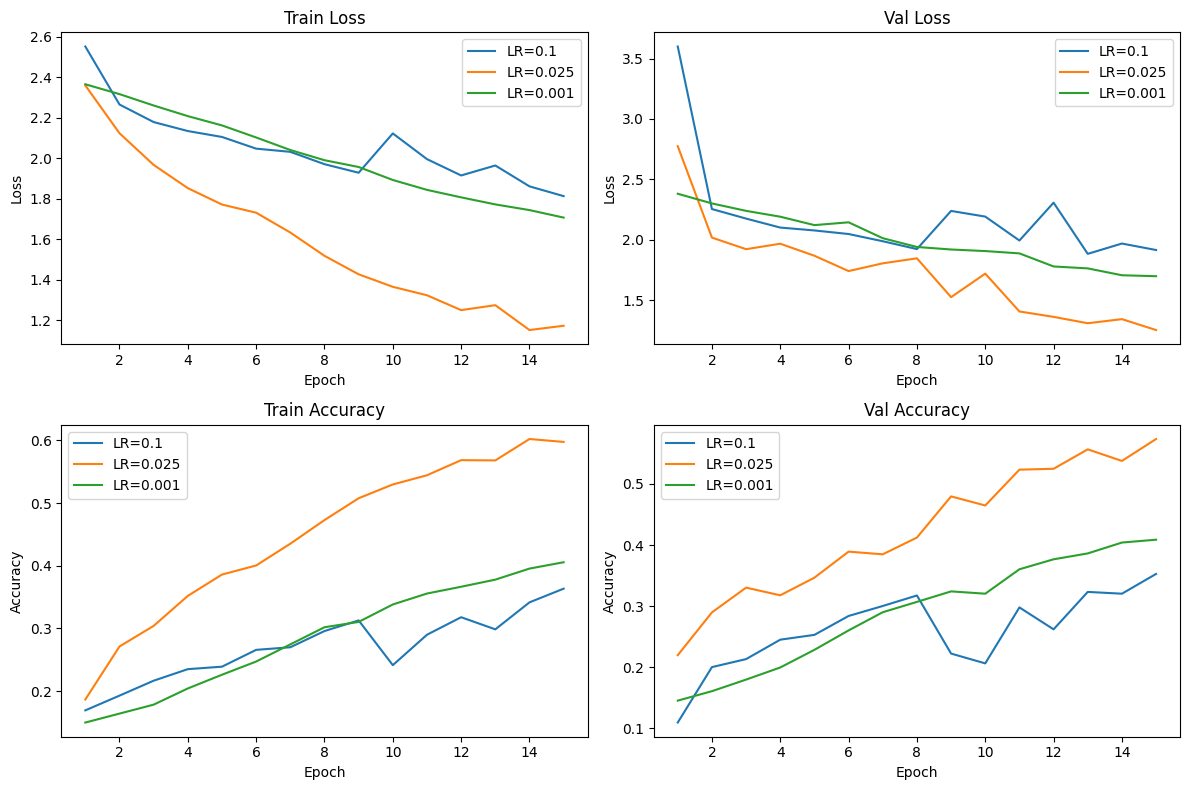

In [10]:
# plot_curves(
#     histories=[lr_histories[lr] for lr in LR_CANDIDATES],
#     labels   =[f'LR={lr}' for lr in LR_CANDIDATES],
#     title='Section 3 Learning Rate'
# )

# ── Separate train and val plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = plt.cm.tab10.colors

for i, lr in enumerate(LR_CANDIDATES):
    c = colors[i % len(colors)]
    hist = lr_histories[lr]
    epochs = range(1, len(hist['train_loss']) + 1)
    
    axes[0, 0].plot(epochs, hist['train_loss'], color=c, label=f'LR={lr}')
    axes[0, 1].plot(epochs, hist['val_loss'], color=c, label=f'LR={lr}')
    axes[1, 0].plot(epochs, hist['train_acc'], color=c, label=f'LR={lr}')
    axes[1, 1].plot(epochs, hist['val_acc'], color=c, label=f'LR={lr}')

axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].set_title('Train Loss'); axes[0, 0].legend()
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss'); axes[0, 1].set_title('Val Loss'); axes[0, 1].legend()
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].set_title('Train Accuracy'); axes[1, 0].legend()
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].set_title('Val Accuracy'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig('Section_3_Learning_Rate_Separated.png', dpi=150)
plt.show()

---
## 4 — Learning Rate Schedule
### 4.1 Cosine Annealing — Description
Cosine annealing smoothly reduces the learning rate following a cosine curve:

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\!\left(\frac{\pi\, t}{T}\right)\right)$$

where $\eta_0$ is the initial learning rate, $\eta_{\min}$ is the minimum (here 0), $t$ is the current epoch and $T$ is the total number of epochs.  
Intuitively the schedule starts fast, then decelerates gently, allowing the optimiser to refine the solution in flat basins rather than oscillating around a minimum.

### 4.2 Experiment
Two conditions, both 300 epochs with the best initial LR from Section 3:
1. **Constant LR** — no schedule
2. **Cosine annealing** — LR decays from `BEST_LR` to 0 over 300 epochs

In [16]:
BEST_LR = 0.025
criterion   = nn.CrossEntropyLoss()

In [ ]:
NUM_EPOCHS_SCHED = 300

# ── Condition 1: constant LR ──────────────────────────────────────────────────
print('── Constant LR ──')
run_const   = wandb.init(
    project='ineedfood',
    name='sec4-constant-lr',
    config={'section': 4, 'lr': BEST_LR, 'epochs': NUM_EPOCHS_SCHED,
            'schedule': 'none', 'optimizer': 'SGD', 'momentum': 0.9,
            'weight_decay': 0.0, 'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_const = build_model()
opt_const   = torch.optim.SGD(model_const.parameters(), lr=BEST_LR,
                               momentum=0.9, weight_decay=0.0)
hist_const  = run_training(model_const, train_loader, val_loader,
                            opt_const, criterion,
                            num_epochs=NUM_EPOCHS_SCHED, tag='Constant',
                            wandb_run=run_const)
report_final(hist_const, 'Constant LR')
run_const.finish()

# ── Condition 2: cosine annealing ─────────────────────────────────────────────
print('\n── Cosine Annealing ──')
run_cos   = wandb.init(
    project='ineedfood',
    name='sec4-cosine-anneal',
    config={'section': 4, 'lr': BEST_LR, 'epochs': NUM_EPOCHS_SCHED,
            'schedule': 'cosine', 'optimizer': 'SGD', 'momentum': 0.9,
            'weight_decay': 0.0, 'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_cos = build_model()
opt_cos   = torch.optim.SGD(model_cos.parameters(), lr=BEST_LR,
                             momentum=0.9, weight_decay=0.0)
sched_cos = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_cos, T_max=NUM_EPOCHS_SCHED, eta_min=0.0)
hist_cos  = run_training(model_cos, train_loader, val_loader,
                          opt_cos, criterion,
                          num_epochs=NUM_EPOCHS_SCHED,
                          scheduler=sched_cos, tag='CosineAnneal',
                          wandb_run=run_cos)
report_final(hist_cos, 'Cosine Annealing')
run_cos.finish()

print('\nSection 4 done.')

── Constant LR ──


[Constant] Epoch   1/300  loss 2.3823/5.0904  acc 0.166/0.182  (3.0s)
[Constant] Epoch   2/300  loss 2.2403/2.2260  acc 0.227/0.280  (3.1s)
[Constant] Epoch   3/300  loss 2.0244/2.0646  acc 0.300/0.297  (3.1s)
[Constant] Epoch   4/300  loss 1.9346/1.8640  acc 0.326/0.342  (3.1s)
[Constant] Epoch   5/300  loss 1.8335/1.7497  acc 0.364/0.380  (3.1s)
[Constant] Epoch  10/300  loss 1.4921/1.5230  acc 0.478/0.486  (3.0s)
[Constant] Epoch  20/300  loss 1.0564/1.2064  acc 0.636/0.617  (3.1s)
[Constant] Epoch  30/300  loss 0.7786/1.0873  acc 0.730/0.654  (3.2s)
[Constant] Epoch  40/300  loss 0.6520/1.1334  acc 0.775/0.655  (3.1s)
[Constant] Epoch  50/300  loss 0.4997/1.1014  acc 0.828/0.678  (3.1s)
[Constant] Epoch  60/300  loss 0.4071/1.1527  acc 0.860/0.685  (3.1s)
[Constant] Epoch  70/300  loss 0.3392/1.1816  acc 0.885/0.695  (3.0s)
[Constant] Epoch  80/300  loss 0.2655/1.2065  acc 0.913/0.699  (3.1s)
[Constant] Epoch  90/300  loss 0.1818/1.3031  acc 0.936/0.710  (3.1s)
[Constant] Epoch 100

Constant/train_acc,▁▁▂▃▄▄▅▅▆▇▇▇▇▇▇▇▇▇▇▇▇▆▇█████████████████
Constant/train_loss,██▇▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Constant/val_acc,▁▁▆▇▇▇▇▇▇▇▇▇▇███████████████████████████
Constant/val_loss,█▅▄▁▁▂▂▃▃▃▄▃▂▃▄▃▅▄▅▄▅▄▄▄▄▆▆▄▄▄▆▅▅▅▅▅▃▇▆▆
Constant/train_acc,0.99068
Constant/train_loss,0.02832
Constant/val_acc,0.72682
Constant/val_loss,1.57389



── Cosine Annealing ──


[CosineAnneal] Epoch   1/300  loss 2.3672/3.0457  acc 0.179/0.214  (3.1s)
[CosineAnneal] Epoch   2/300  loss 2.2094/11.0092  acc 0.249/0.199  (3.2s)
[CosineAnneal] Epoch   3/300  loss 2.0205/2.1735  acc 0.290/0.270  (3.0s)
[CosineAnneal] Epoch   4/300  loss 1.9407/1.8510  acc 0.316/0.359  (3.2s)
[CosineAnneal] Epoch   5/300  loss 1.8179/1.8584  acc 0.366/0.360  (3.2s)
[CosineAnneal] Epoch  10/300  loss 1.3947/1.4983  acc 0.526/0.503  (3.1s)
[CosineAnneal] Epoch  20/300  loss 0.9660/1.2358  acc 0.668/0.584  (3.1s)
[CosineAnneal] Epoch  30/300  loss 0.8230/1.0853  acc 0.718/0.649  (3.2s)
[CosineAnneal] Epoch  40/300  loss 0.6813/1.0904  acc 0.759/0.661  (3.3s)
[CosineAnneal] Epoch  50/300  loss 0.5048/1.1407  acc 0.822/0.676  (3.1s)
[CosineAnneal] Epoch  60/300  loss 0.5041/1.2829  acc 0.824/0.624  (3.2s)
[CosineAnneal] Epoch  70/300  loss 0.3901/1.1417  acc 0.864/0.688  (3.1s)
[CosineAnneal] Epoch  80/300  loss 0.2658/1.4352  acc 0.911/0.661  (3.0s)
[CosineAnneal] Epoch  90/300  loss 0.

CosineAnneal/train_acc,▁▂▂▄▅▆▇▆▇▇▇█▇▇▇▆▇▆▇█████████████████████
CosineAnneal/train_loss,█▇▆▅▅▃▃▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CosineAnneal/val_acc,▄▂▅▆▅▅▁▅▆▇▇▆▇▇▇▇▇▇▇▇████████████████████
CosineAnneal/val_loss,█▂▁▂▂▁▂▁▂▂▂▂▁▂▂▂▂▂▂▃▂▂▃▃▃▄▃▃▃▃▄▄▄▄▄▄▄▄▄▄
CosineAnneal/train_acc,0.99666
CosineAnneal/train_loss,0.0158
CosineAnneal/val_acc,0.70962
CosineAnneal/val_loss,1.83626



Section 4 done.


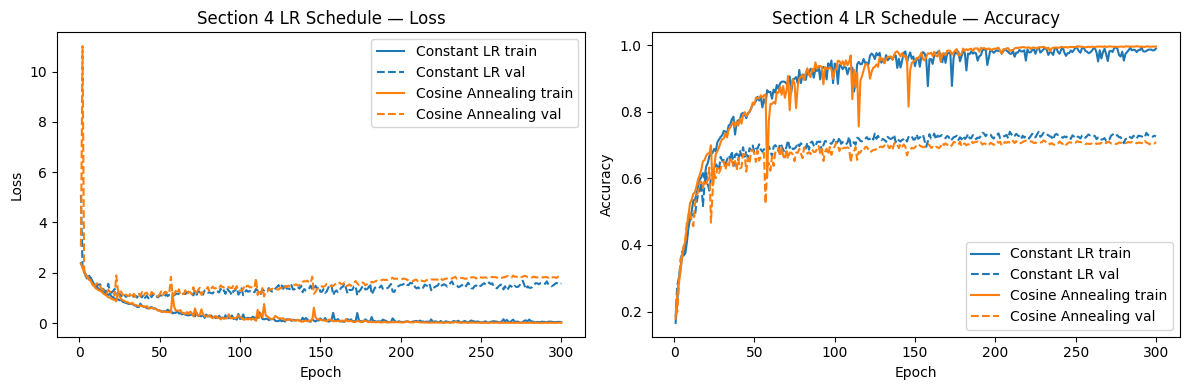

In [12]:
plot_curves(
    histories=[hist_const, hist_cos],
    labels   =['Constant LR', 'Cosine Annealing'],
    title='Section 4 LR Schedule'
)

---
## 5 — Weight Decay
Best LR + cosine annealing + weight decay λ ∈ {5×10⁻⁴, 1×10⁻⁴} | 300 epochs

In [12]:
WD_VALUES = [5e-4, 1e-4]
NUM_EPOCHS_WD = 300

wd_histories = {}

In [ ]:

for wd in WD_VALUES:
    print(f'\n──── Weight Decay λ = {wd} ────────────────────────')
    run = wandb.init(
        project='ineedfood',
        name=f'sec5-wd={wd}',
        config={'section': 5, 'lr': BEST_LR, 'weight_decay': wd,
                'epochs': NUM_EPOCHS_WD, 'schedule': 'cosine',
                'optimizer': 'SGD', 'momentum': 0.9,
                'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
    )
    model_wd = build_model()
    opt_wd   = torch.optim.SGD(model_wd.parameters(), lr=BEST_LR,
                                momentum=0.9, weight_decay=wd)
    sched_wd = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_wd, T_max=NUM_EPOCHS_WD, eta_min=0.0)
    hist_wd  = run_training(model_wd, train_loader, val_loader,
                             opt_wd, criterion,
                             num_epochs=NUM_EPOCHS_WD,
                             scheduler=sched_wd, tag=f'WD={wd}',
                             wandb_run=run)
    wd_histories[wd] = hist_wd
    report_final(hist_wd, f'Weight Decay λ={wd}')
    run.finish()

print('\nSection 5 done.')


──── Weight Decay λ = 0.0001 ────────────────────────


[WD=0.0001] Epoch   1/300  loss 2.3614/3.3172  acc 0.169/0.190  (4.2s)
[WD=0.0001] Epoch   2/300  loss 2.2412/2.1862  acc 0.240/0.271  (3.2s)
[WD=0.0001] Epoch   3/300  loss 2.0047/1.9421  acc 0.301/0.351  (3.2s)
[WD=0.0001] Epoch   4/300  loss 1.8976/1.9552  acc 0.339/0.337  (3.0s)
[WD=0.0001] Epoch   5/300  loss 1.8359/1.9548  acc 0.360/0.339  (3.1s)
[WD=0.0001] Epoch  10/300  loss 1.5044/1.5414  acc 0.489/0.473  (3.0s)
[WD=0.0001] Epoch  20/300  loss 1.0515/1.2127  acc 0.638/0.602  (3.1s)
[WD=0.0001] Epoch  30/300  loss 1.5217/1.6047  acc 0.472/0.439  (3.1s)
[WD=0.0001] Epoch  40/300  loss 0.9498/1.1545  acc 0.668/0.617  (3.1s)
[WD=0.0001] Epoch  50/300  loss 0.7466/1.1517  acc 0.741/0.627  (3.1s)
[WD=0.0001] Epoch  60/300  loss 0.5512/1.1924  acc 0.808/0.654  (3.1s)
[WD=0.0001] Epoch  70/300  loss 0.5285/1.1303  acc 0.814/0.668  (3.1s)
[WD=0.0001] Epoch  80/300  loss 0.3868/1.1841  acc 0.866/0.669  (3.1s)
[WD=0.0001] Epoch  90/300  loss 0.3565/1.2514  acc 0.878/0.671  (3.1s)
[WD=0.

In [10]:
# Compare: no weight decay (cosine, Section 4) vs two WD values
plot_curves(
    histories=[hist_cos] + [wd_histories[wd] for wd in WD_VALUES],
    labels   =['No WD (cosine)'] + [f'WD λ={wd}' for wd in WD_VALUES],
    title='Section 5 Weight Decay'
)

NameError: name 'hist_cos' is not defined

---
## 6 — Data Augmentation: Mixup (α = 0.2)

### Beta Distribution PDF (α = β = 0.2)

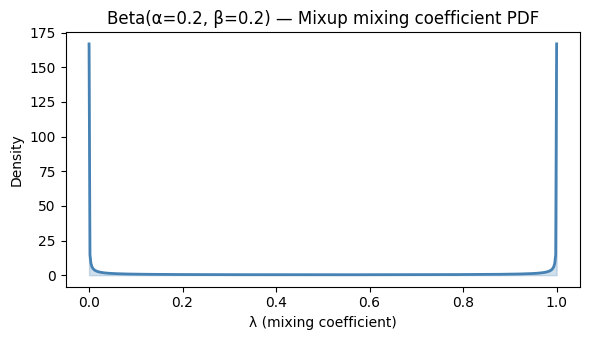

The U-shaped PDF concentrates mass near 0 and 1, so most mixed samples are close to one of the two originals.


In [9]:
from scipy.stats import beta as beta_dist

alpha_mixup = 0.2
x = np.linspace(1e-4, 1 - 1e-4, 500)
pdf = beta_dist.pdf(x, a=alpha_mixup, b=alpha_mixup)

plt.figure(figsize=(6, 3.5))
plt.plot(x, pdf, color='steelblue', linewidth=2)
plt.fill_between(x, pdf, alpha=0.25, color='steelblue')
plt.xlabel('λ (mixing coefficient)')
plt.ylabel('Density')
plt.title(f'Beta(α={alpha_mixup}, β={alpha_mixup}) — Mixup mixing coefficient PDF')
plt.tight_layout()
plt.savefig('beta_pdf.png', dpi=150)
plt.show()
print('The U-shaped PDF concentrates mass near 0 and 1, '
      'so most mixed samples are close to one of the two originals.')

In [10]:
# ── Mixup helpers ─────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x  = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch_mixup(model, loader, optimizer, criterion, alpha=0.2):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        mixed, y_a, y_b, lam = mixup_data(imgs, labels, alpha=alpha)
        optimizer.zero_grad()
        with torch.autocast(**_AMP_CTX):
            logits = model(mixed)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        pred = logits.detach().argmax(1)
        correct += (lam * (pred == y_a).float() +
                    (1 - lam) * (pred == y_b).float()).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def run_training_mixup(model, train_loader, val_loader, optimizer, criterion,
                       num_epochs, scheduler=None, alpha=0.2, tag='',
                       wandb_run=None):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_mixup(model, train_loader,
                                                 optimizer, criterion, alpha)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if wandb_run is not None:
            wandb_run.log({
                f'{tag}/train_loss': tr_loss, f'{tag}/val_loss': vl_loss,
                f'{tag}/train_acc':  tr_acc,  f'{tag}/val_acc':  vl_acc,
                f'{tag}/epoch':      epoch,
            })
        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch <= 5 or epoch == num_epochs:
            print(f'[{tag}] Epoch {epoch:3d}/{num_epochs}  '
                  f'loss {tr_loss:.4f}/{vl_loss:.4f}  '
                  f'acc {tr_acc:.3f}/{vl_acc:.3f}  '
                  f'({elapsed:.1f}s)')
    return history


print('Mixup helpers ready.')

Mixup helpers ready.


In [14]:
# Best setup so far: BEST_LR + cosine annealing + best weight decay
BEST_WD = 5e-4
print(f'Best weight decay from Section 5: {BEST_WD}')

Best weight decay from Section 5: 0.0005


In [18]:
NUM_EPOCHS_MIX = 300
ALPHA_MIXUP    = 0.2

# ── Mixup α=0.2 ───────────────────────────────────────────────────────────────
print('\n── Mixup (α=0.2) ──')
run_mix = wandb.init(
    project='ineedfood',
    name='sec6-mixup-a0.2',
    config={'section': 6, 'lr': BEST_LR, 'weight_decay': BEST_WD,
            'epochs': NUM_EPOCHS_MIX, 'schedule': 'cosine',
            'mixup': True, 'mixup_alpha': ALPHA_MIXUP,
            'optimizer': 'SGD', 'momentum': 0.9,
            'batch_size': BATCH_SIZE, 'model': 'EfficientNet-B0'},
)
model_mix = build_model()
opt_mix   = torch.optim.SGD(model_mix.parameters(), lr=BEST_LR,
                             momentum=0.9, weight_decay=BEST_WD)
sched_mix = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_mix, T_max=NUM_EPOCHS_MIX, eta_min=0.0)
criterion = nn.CrossEntropyLoss()
hist_mix  = run_training_mixup(model_mix, train_loader, val_loader,
                                opt_mix, criterion,
                                num_epochs=NUM_EPOCHS_MIX,
                                scheduler=sched_mix,
                                alpha=ALPHA_MIXUP, tag='Mixup',
                                wandb_run=run_mix)
report_final(hist_mix, 'Mixup α=0.2')

print('\nSection 6 done.')


── Mixup (α=0.2) ──


train_acc,▁▃▆▇█
train_loss,█▆▃▂▁
val_acc,▁▃▆▆█
val_loss,█▅▃▂▁
train_acc,0.35658
train_loss,1.81231
val_acc,0.36035
val_loss,1.83778


[Mixup] Epoch   1/300  loss 2.3641/6.6054  acc 0.169/0.147  (3.4s)
[Mixup] Epoch   2/300  loss 2.1895/2.6443  acc 0.240/0.251  (3.1s)
[Mixup] Epoch   3/300  loss 2.0684/3.5101  acc 0.282/0.264  (3.0s)
[Mixup] Epoch   4/300  loss 1.9792/1.9258  acc 0.314/0.339  (3.1s)
[Mixup] Epoch   5/300  loss 1.9208/1.8923  acc 0.329/0.344  (3.1s)
[Mixup] Epoch  10/300  loss 1.6856/1.4999  acc 0.432/0.482  (3.1s)
[Mixup] Epoch  20/300  loss 1.3125/1.2249  acc 0.582/0.598  (3.1s)
[Mixup] Epoch  30/300  loss 1.1206/1.0608  acc 0.648/0.654  (3.1s)
[Mixup] Epoch  40/300  loss 1.0504/1.0028  acc 0.686/0.666  (3.1s)
[Mixup] Epoch  50/300  loss 1.0083/0.9133  acc 0.702/0.701  (3.2s)
[Mixup] Epoch  60/300  loss 0.9483/1.0306  acc 0.724/0.687  (3.1s)
[Mixup] Epoch  70/300  loss 0.9125/0.9606  acc 0.734/0.684  (3.0s)
[Mixup] Epoch  80/300  loss 0.9283/0.8861  acc 0.739/0.718  (3.1s)
[Mixup] Epoch  90/300  loss 0.9209/0.9586  acc 0.748/0.710  (3.1s)
[Mixup] Epoch 100/300  loss 0.7779/2.2456  acc 0.783/0.713  (3

In [1]:
plot_curves(
    histories=[hist_base, hist_mix],
    labels   =['No Mixup', 'Mixup α=0.2'],
    title='Section 6 Mixup Augmentation'
)

NameError: name 'plot_curves' is not defined

In [ ]:
# ── Final test-set accuracy ───────────────────────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()

# Mixup model — evaluated fresh on test set
test_loss_mix, test_acc_mix = evaluate(model_mix, test_loader, criterion_eval)

print('=== Hold-out Test Set Results ===')
print(f'  No Mixup (sec5 baseline) — val acc : {hist_base["val_acc"][-1]:.4f}  (test eval skipped, model not retained)')
print(f'  Mixup 0.2               — test acc : {test_acc_mix:.4f} ({test_acc_mix*100:.2f}%)')

run_mix.summary['test_loss'] = test_loss_mix
run_mix.summary['test_acc']  = test_acc_mix
run_mix.finish()